# Image to fMRI occlusion pathfinder

The goal of this notebook is to explore whether we can get any interpretable response to occlusion in the NeuroFlow encoder model. The underlying assumption is that high-level semantic features within the images are primarily encoded in the related functional region of the brain (e.g. `faces`, `bodies`, `places`). As `places` usually refer to the entirety of a visual scene, we restrict first occlusion experiements to the `faces` and `bodies` functional areas.

# Sampling and occluding images

We start by selecting a fitting subset of images and manually (via GIMP) applying occluding transformations to obviously alter the semantic content relating to `faces` and `bodies`.

In [1]:
from PIL import Image
import os
import matplotlib.pyplot as plt

The original, unaltered images.


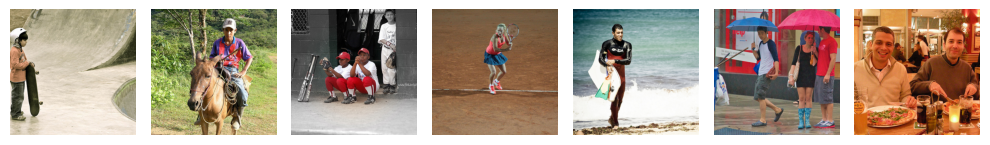

Images with black bounding boxes applied to regions with humans.


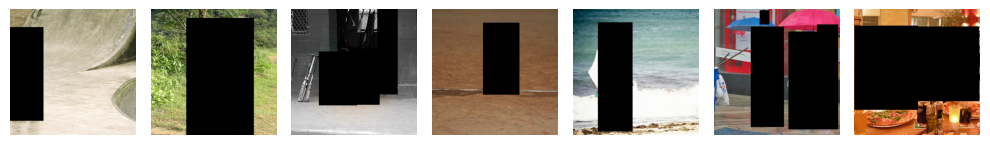

Images with Gaussian blur applied manually to regions with humans.


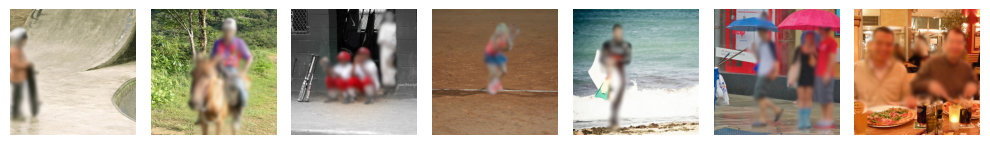

Images with smudge aggressivly applied manually to regions with humans.


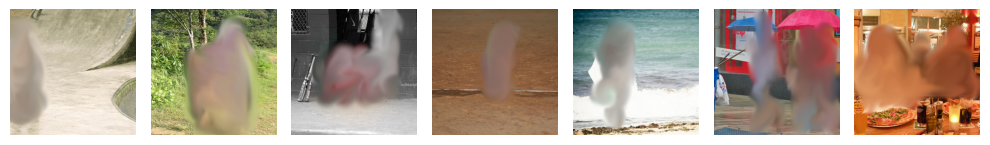

Images with Gaussian blur applied manually to regions with human faces.


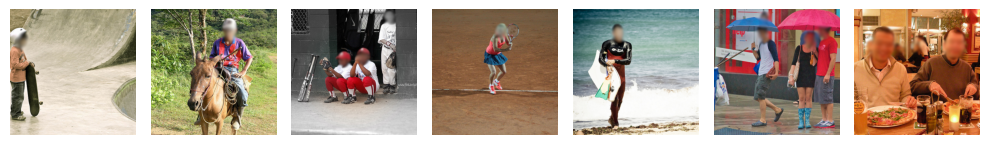

In [ ]:
img_ids = [62, 90, 223, 413, 444, 485, 938]

settings = {
    "original": "The original, unaltered images.",
    "black": "Images with black bounding boxes applied to regions with humans.",
    "blur": "Images with Gaussian blur applied manually to regions with humans.",
    "smudge": "Images with smudge aggressivly applied manually to regions with humans.",
    "blur_faces": "Images with Gaussian blur applied manually to regions with human faces."
}

for setting, title in settings.items():
    print(title)

    plt.figure(figsize=(10, 2))
    image_path = f"image_data/images_{setting}"
    for i, img_id in enumerate(img_ids):
        img = Image.open(os.path.join(image_path, f"{img_id}.png"))
        plt.subplot(1, len(img_ids), i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# fMRI quantitative deviation

In this section, sythetic fMRI encodings of the maipulated samples are compared to the unmanipulated one as well as to the ground truth fMRI according to regions of interest.

In [9]:
import torch
import os

# Prepare ground truth fMRI to same format as reconstructions
gt_fmri_all = torch.load("/u/fdammeier/repositories/NeuroFlow/sample_data/fmri_zscores.pt")

# This is the unsampled version, we have to extract the corresponding samples according to their indices
img_path = "/u/fdammeier/repositories/NeuroFlow/sample_data/images"
img_indices = [int(f.split(".")[0]) for f in os.listdir(img_path)]
img_indices.sort()
sample_indices = [img_indices.index(i) for i in img_ids]

gt_fmri = gt_fmri_all[sample_indices]

In [30]:
# the reconstructed fMRI zscores are obtained from the artifacts path
fmri_dict = {
    setting: torch.load(f"/u/fdammeier/artifacts/image_occlusion_{setting}/reconstructed_fmri.pt").mean(1) # Remove artifical trial dim.
    for setting in ["original", "black", "blur", "smudge", "blur_faces"]
}

fmri_dict["ground_truth"] = gt_fmri.mean(1) # Mean across trials can be questioned, taken from NeuroFlow
fmri_dict["ground_truth"].shape # display sample shape

torch.Size([7, 15724])

In [31]:
# Transform data to voxel space for ROI based analysis
from fmri_utils import transform_to_voxel_space
import numpy as np
nsd_general_mask_path = "../../sample_data/roi/nsdgeneral.nii.gz"

fmri_voxel_dict = {
    setting: np.array([
        transform_to_voxel_space(sample, nsd_general_mask_path).get_fdata() 
        for sample in flattened.numpy()
    ])
    for setting, flattened in fmri_dict.items()
}

In [28]:
# Define ROI masks. We will use all available ROIs for every fLoc experiment
import nibabel as nib

def get_roi_mask(roi_ids, mask_file):
    mask_img = nib.load(mask_file)
    mask_data = mask_img.get_fdata()
    roi_mask = np.isin(mask_data, roi_ids)
    return roi_mask

roi_masks = {
    'general': get_roi_mask(roi_ids=[1], mask_file='../../sample_data/roi/nsdgeneral.nii.gz'),
    'bodies': get_roi_mask(roi_ids=[1, 2, 3, 4], mask_file='../../sample_data/roi/floc-bodies.nii.gz'),
    'faces': get_roi_mask(roi_ids=[1, 2, 3, 4, 5], mask_file='../../sample_data/roi/floc-faces.nii.gz'),
    'places': get_roi_mask(roi_ids=[1, 2, 3], mask_file='../../sample_data/roi/floc-places.nii.gz')
}

In [ ]:
fmri_ground_truth = fmri_voxel_dict.pop("ground_truth")
fmri_recon_original = fmri_voxel_dict.pop("original")

In [56]:
# we want to be able to calculate distances across different metrics and against different ground truths

def evaluate_fmri_reconstructions(fmri_dict, ground_truth, roi_masks, metric):
    """
    Metric is a function that takes two arguments (x, gt) and
    returns an array of distances for each sample along axis 0.
    """
    results = {}

    for roi_name, roi_mask in roi_masks.items():
        for setting, fmri_data in fmri_dict.items():
            fmri_roi = fmri_data[:, roi_mask]
            gt_roi = ground_truth[:, roi_mask]

            distance = metric(fmri_roi, gt_roi)
            distance_stats = {
                'min': distance.min(),
                'max': distance.max(),
                'mean': distance.mean(),
                'std': distance.std()
            }

            if roi_name not in results:
                results[roi_name] = {}
            results[roi_name][setting] = distance_stats

    return results

# mean square error as simple baseline metric
def mse(x, gt):
    return ((x - gt) ** 2).mean(axis=1)

# a common metric for comparing fMRI data is correlation
def correlation(x, gt):
    return np.array([
        np.corrcoef(x[i], gt[i], rowvar=False)[0, 1]
        for i in range(x.shape[0])
    ])

# for good measure we throw in Cosine similarity
def cosine_similarity(x, gt):
    return np.array([
        np.dot(x[i], gt[i]) / (np.linalg.norm(x[i]) * np.linalg.norm(gt[i]))
        for i in range(x.shape[0])
    ])

def pretty_print_metrics(metrics):
    # Print header
    settings = list(next(iter(metrics.values())).keys())
    header = "| ROI Name | " + " | ".join(f"{setting:14}" for setting in settings) + " |"
    separator = "| -------- | " + " | ".join("-" * 14 for _ in settings) + " |"
    print(header)
    print(separator)

    for roi_name, roi_values in metrics.items():
        row = f"| {roi_name:8} | "
        row += " | ".join(
            f"{v['mean']: .3f} ({v['std']:.3f})"
            for v in roi_values.values()
        )
        row += " |"
        print(row)


In [57]:
metrics_dict = {
    "MSE": mse,
    "Correlation": correlation,
    "Cosine": cosine_similarity
}

gt_dict = {
    "Original Reconstructed": fmri_recon_original,
    "Ground Truth fMRI": fmri_ground_truth
}

for gt_name, gt_data in gt_dict.items():
    print(f"Evaluating against ground truth: {gt_name}")
    for metric_name, metric_func in metrics_dict.items():
        print(f"Using metric: {metric_name}")
        results = evaluate_fmri_reconstructions(
            fmri_dict=fmri_voxel_dict,
            ground_truth=gt_data,
            roi_masks=roi_masks,
            metric=metric_func
        )
        pretty_print_metrics(results)
        print()

Evaluating against ground truth: Original Reconstructed
Using metric: MSE
| ROI Name | black          | blur           | smudge         | blur_faces     |
| -------- | -------------- | -------------- | -------------- | -------------- |
| general  |  0.183 (0.046) |  0.059 (0.009) |  0.099 (0.020) |  0.014 (0.005) |
| bodies   |  0.249 (0.091) |  0.050 (0.012) |  0.113 (0.033) |  0.011 (0.005) |
| faces    |  0.199 (0.091) |  0.052 (0.014) |  0.096 (0.045) |  0.009 (0.005) |
| places   |  0.120 (0.068) |  0.060 (0.025) |  0.056 (0.020) |  0.014 (0.008) |

Using metric: Correlation
| ROI Name | black          | blur           | smudge         | blur_faces     |
| -------- | -------------- | -------------- | -------------- | -------------- |
| general  |  0.164 (0.222) |  0.734 (0.073) |  0.516 (0.146) |  0.946 (0.031) |
| bodies   | -0.043 (0.196) |  0.799 (0.078) |  0.476 (0.100) |  0.961 (0.023) |
| faces    |  0.083 (0.221) |  0.764 (0.051) |  0.493 (0.179) |  0.951 (0.038) |
| places

# Image reconstructions

In this section the synthetic fMRI betas obtained by the NeuroFlow encoding pipeline are decoded again to Images. We qualitatively examine the images across settings.

Reconstructing the original images.


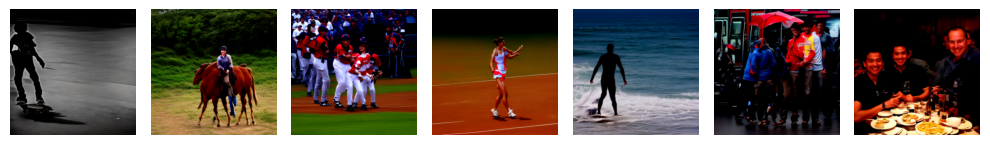

Reconstructing images with black bounding boxes applied to regions with humans.


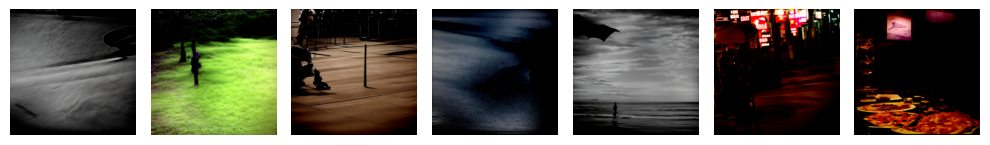

Reconstructing images with Gaussian blur applied manually to regions with humans.


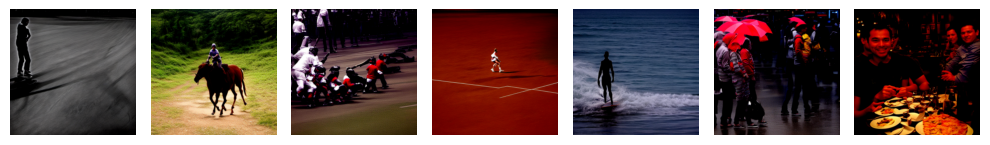

Reconstructing images with smudge aggressivly applied manually to regions with humans.


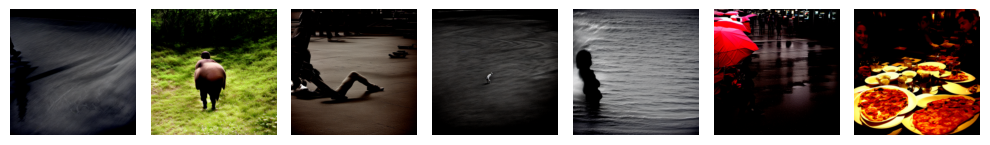

Reconstructing images with Gaussian blur applied manually to regions with human faces.


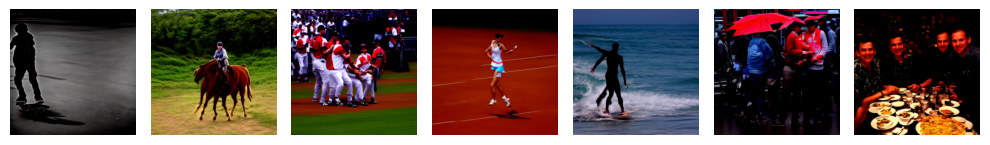

In [ ]:
settings_recon = {
    "original": "Reconstructing the original images.",
    "black": "Reconstructing images with black bounding boxes applied to regions with humans.",
    "blur": "Reconstructing images with Gaussian blur applied manually to regions with humans.",
    "smudge": "Reconstructing images with smudge aggressivly applied manually to regions with humans.",
    "blur_faces": "Reconstructing images with Gaussian blur applied manually to regions with human faces."
}

for setting, title in settings_recon.items():
    print(title)

    plt.figure(figsize=(10, 2))
    image_path = f"/u/fdammeier/artifacts/image_occlusion_recon_{setting}/reconstructed_images"
    for i in range(len(img_ids)):
        img = Image.open(os.path.join(image_path, f"{i}.png"))
        plt.subplot(1, len(img_ids), i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# Discussion